<table style="width: 100%; border-style: none;">
<tr style="border-style: none">
<td style="border-style: none; width: 1%; text-align: left; font-size: 16px">Institut f&uuml;r Theoretische Physik<br /> Universit&auml;t zu K&ouml;ln</td>
<td style="border-style: none; width: 1%; font-size: 16px">&nbsp;</td>
<td style="border-style: none; width: 1%; text-align: right; font-size: 16px">Prof. Dr. Matteo Rizzi
</tr>
</table>
<hr>
<h1 style="font-weight:bold; text-align: center; margin: 0px; font-size: 30px; padding:0px;">Computerphysik</h1>
<h1 style="font-weight:bold; text-align: center; margin: 0px; font-size: 30px; padding:0px;">Übungsblatt 10</h1>
<hr>
<h3 style="font-weight:bold; text-align: center; margin: 0px; font-size: 20px; padding:0px; margin-bottom: 20px;">Sommersemester 2026</h3>
<hr>


<table style="border-style: none; width: 100%"><tr style="border-style: none;">
<td style="border-style: none; width: 1%; text-align: left; font-size: 25px; font-weight: bold; text-decoration: underline">Aufgaben auf Übungsblatt 10</td>
<td style="border-style: none; width: 1%; text-align: right; font-size: 15px"></td></tr></table>

- Aufgabe 10_01: Gleichverteilung auf der Kugeloberfläche
- **Aufgabe 10_02: Monte Carlo-Integration I**
- Aufgabe 10_03: Monte Carlo-Integration II
- Aufgabe 10_04: Chaos Game 

<table style="border-style: none; width: 100%"><tr style="border-style: none;">
<td style="border-style: none; width: 1%; text-align: left; font-size: 25px; font-weight: bold; text-decoration: underline">Aufgabe 2: 
Monte Carlo-Integration</td>


In dieser Aufgabe wollen wir uns mit der Integration von Funktionen mithilfe von Zufallszahlen befassen. Die ersten Schritte in diese Richtung haben wir in der Vorlesung besprochen und wir wollen nun an einfachen Beispielen die verschiedenen Sampling-Methoden untersuchen. 

Um Ihnen in dieser Aufgabe den Einstieg zu erleichtern, finden Sie im Folgenden zunächst ein paar Beispiele, wie Sie Funktionen mit dem Paket `Cubature` integrieren, sowie Zufallszahlen mit dem Paket `Distributions` erzeugen können.

#### Beispiel zur numerischen Integration

In [4]:
using Cubature
f(x) = x^2
(value, err) = hquadrature(f, -1, 1)

(0.6666666666666667, 7.401486830834377e-15)

#### Beispiel zur Erzeugung normalverteilter Zufallszahlen

In [2]:
using Distributions
mu = 0.5
sigma = 0.1
random_number_generator = Normal(mu, sigma)
rand(random_number_generator)

0.5424125223244166

#### Beispiel zum Vergleich normalverteilter Zufallszahlen mit einer Normalverteilung

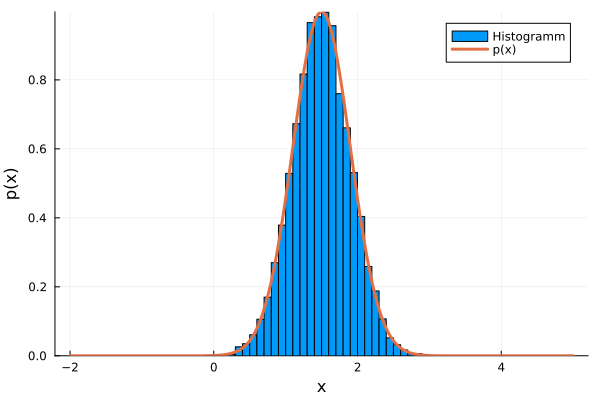

In [3]:
using Plots

mu = 1.5
sigma = 0.4

random_number_generator = Normal(mu, sigma)
rands = [rand(random_number_generator) for i in 1:10000]
histogram(rands, bins=30, normalize=true, label="Histogramm")

p(x) = 1/sqrt(2*pi*sigma^2)*exp(-(x-mu)^2/(2*sigma^2))
plot!(-2:0.01:5, p.(-2:0.01:5), label="p(x)", linewidth = 3)

xlabel!("x")
ylabel!("p(x)")

### a) Gleichförmig verteilte Zufallszahlen 

Beginnen wir mit der folgenden Funktion:
\begin{equation}
f(x) = 2 - 0.1\cdot\sin(x),\quad x\in [0, \pi]
\end{equation}

- Sie können sich durch simples Plotten leicht davon überzeugen, dass die Funktion relativ flach ist und sich deshalb dazu eignet mit einer gleichförmigen Verteilung integriert zu werden. 
- Führen Sie nun eine Integration dieser Funktion mit bis zu $N=10^6$ *gleichförmig verteilten* Zufallszahlen durch und plotten Sie das Ergebnis der Integration gegen die Anzahl gezogener Zufallszahlen $N$. 
- Vergleichen Sie außerdem Ihr Ergebnis mit der numerischen Lösung, die Sie mit der Paket *Cubature* bestimmen können.
- Schreiben Sie pseudo-code, der die Integration der Funktion f auf dem gegeben Interval mit gleichförmig verteilten Zufallszahlen beschreibt.

###  b) Normalverteilte Zufallszahlen 

Als nächstes betrachten wir die Funktion
\begin{equation}
g(x) = \cos(x) \cdot \exp{\left(-\dfrac{x^2}{0.08}\right)},\quad x \in (-\infty, \infty)
\end{equation}

Bereits auf den ersten Blick ist klar, dass das Integral dieser Funktion hauptsächlich durch einen kleinen Bereich um 0 bestimmt wird. Deshalb ist es zunächst einmal zulässig den Integrationsbereich auf ein endliches Intervall, zum Beispiel $(-30, 30)$, einzuschränken. 

- Bestimmen Sie das Integral nun wie zuvor mithilfe einer gleichförmig verteilten Zufallsverteilung und plotten Sie das Ergebnis als Funktion der Anzahl gezogener Zufallszahlen. 

- Benutzen Sie dann die Generatoren aus dem Paket `Distributions`, um Zufallszahlen gemäß einer Gaussverteilung mit Mittelwert $\mu$ und Standardabweichung $\sigma$ zu erzeugen. Passen Sie diese Parameter so an, dass die Form der gesampleten Gauß-Kurve möglichst genau der Funktion $g(x)$ entspricht und führen Sie auch diese Integration durch und vergleichen Sie beide Ergebnisse mit der durch `hquadrature` gewonnenen Lösung. 

Beachten Sie, dass Sie mit der Gauß verteilung Zahlen aus $(-\infty, \infty)$ erzeugen. Aufgrund der stark um den Mittelwert zentrierten Form der Verteilung ist der Fehler, den wir gegenüber der Integration mit eingeschränktem Integrationsbereich machen vernachlässigbar. Alternativ könnte man nur Zufallszahlen im Bereich $(-30, 30)$ akzeptieren und die Verteilung neu zu skalieren.
